In [1]:
from pathlib import Path
import ee
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geemap
from src.config import EE_PROJECT_ID, HANSEN_CANOPY_COVER_THRESHOLD, TARGET_SCALE_M, WORLDCOVER_CLASS_TREES, MONTHS, S2_BANDS   
from src.data import get_sumave_aoi, get_base_datasets
from src.processing import get_confirmed_forest_mask, calculate_loss_area_by_year
from src.features import get_all_features

**ABOUT DATASET**

**Hansen Global Forest Change**

Who made it: University of Maryland (UMD), updated annually by Professor Matthew Hansen's team

Duration: 2000 → 2024 (updated every year)

What it contains:

- treecover2000  → canopy cover % per pixel in year 2000
- lossyear       → which year each pixel lost forest cover (2001-2024)
- gain           → forest gain detected between 2000-2012 only
- datamask       → land vs water classification

Resolution: 30m per pixel

Satellite source: Landsat 5, 7, 8, 9

**ESA WorldCover**

Who made it: European Space Agency (ESA)

Duration: Two snapshots only — 2020 (v100) and 2021 (v200). Not a time series.

What it contains:

11 land cover classes per pixel:

- Trees, Shrubland, Grassland, Cropland,
- Built-up, Bare/sparse, Snow/ice,
- Water, Wetland, Mangroves, Moss/lichen

Resolution: 10m per pixel

Satellite source: Sentinel-1 (radar) + Sentinel-2 (optical) combined

In [2]:
FIGURE_PATH = Path('figures')
FIGURE_PATH.mkdir(exist_ok=True)

In [3]:
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "savefig.dpi": 300
})

In [4]:
# Authenticate and initialise
ee.Authenticate()
ee.Initialize(project=EE_PROJECT_ID)

In [5]:
# get aio and datasets
aoi = get_sumave_aoi()
worldcover, hansen = get_base_datasets()

In [6]:
total_area_park_km2 = aoi.area().divide(1e6).getInfo()
print(f"Area of AOI (km²): {total_area_park_km2 :.2f}")

Area of AOI (km²): 682.34


In [7]:
# Create a folium map centered on the AOI
center = [aoi.centroid().getInfo()['coordinates'][1], aoi.centroid().getInfo()['coordinates'][0]]
m = folium.Map(location=center, zoom_start=10)
# Add the AOI to the map
folium.GeoJson(aoi.getInfo()).add_to(m)
m

In [8]:
# Class definitions
class_codes = [10, 20, 30, 40, 50, 60, 80, 90, 95, 100]
class_names = [
    'Trees', 'Shrubland', 'Grassland', 'Cropland',
    'Built-up', 'Bare/sparse', 'Water',
    'Wetland', 'Mangroves', 'Moss/lichen'
]

histogram = worldcover.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=10,    
    maxPixels=1e10,
).getInfo()

In [9]:
histogram

{'Map': {'10': 8230712.698039217,
  '20': 142,
  '30': 2151757.9803921557,
  '40': 17365.63921568628,
  '50': 12519.686274509804,
  '60': 100,
  '80': 6260.603921568627,
  '90': 2047}}

In [10]:
pixel_counts = histogram.get('Map', {})

results = []
for code, name in zip(class_codes, class_names):
        # Calculate area for each class by multiplying 
        area = (worldcover.eq(code)
                .multiply(ee.Image.pixelArea())
                .reduceRegion(
                    reducer=ee.Reducer.sum(),
                    geometry=aoi,
                    scale=10,
                    maxPixels=1e10,
                    bestEffort=True
                ).getInfo())
        # Convert area from m² to km²
        area_km2 = area.get('Map', 0) / 1e6

        results.append({
            'class_code': code,
            'class_name': name,
            'area_km2':   round(area_km2, 2)
        })

df_area = pd.DataFrame(results)

total_area_km2 = df_area['area_km2'].sum()
tree_area_km2 = df_area[df_area['class_code'] == 10]['area_km2'].iloc[0]
df_area['area_percentage'] = round((df_area['area_km2'] / total_area_km2) * 100, 2)

df_area = df_area.sort_values('area_km2', ascending=False).reset_index(drop=True)

print(df_area.to_string(index=False))
print(f'Tree area: {tree_area_km2:.2f} km²')
print(f'Park boundary area from boundary: {total_area_park_km2:.2f} km²')
print(f'Total area from land cover: {total_area_km2:.2f} km²')

 class_code  class_name  area_km2  area_percentage
         10       Trees    540.59            78.98
         30   Grassland    141.37            20.65
         40    Cropland      1.14             0.17
         50    Built-up      0.82             0.12
         80       Water      0.41             0.06
         90     Wetland      0.13             0.02
         20   Shrubland      0.01             0.00
         60 Bare/sparse      0.01             0.00
         95   Mangroves      0.00             0.00
        100 Moss/lichen      0.00             0.00
Tree area: 540.59 km²
Park boundary area from boundary: 682.34 km²
Total area from land cover: 684.48 km²


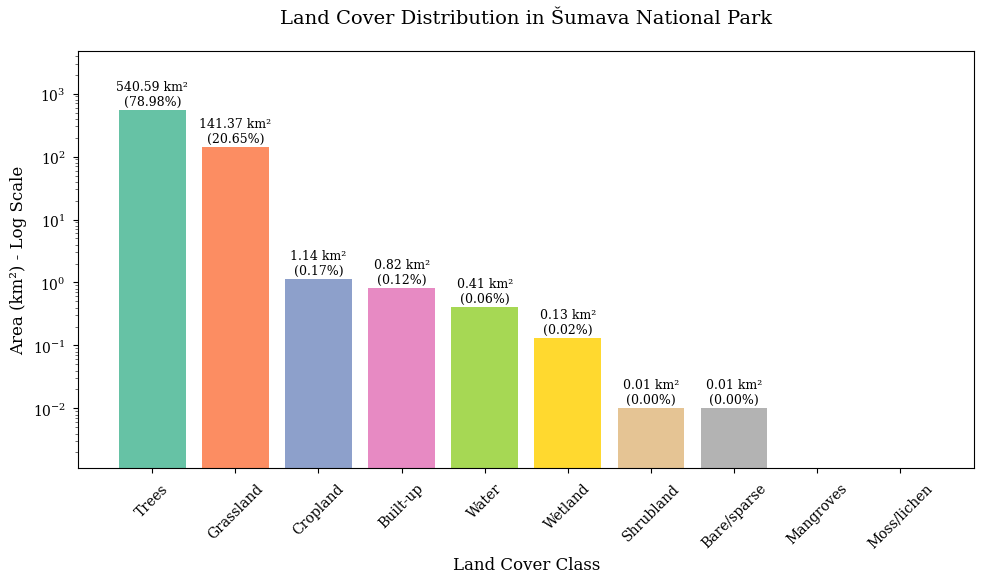

In [11]:
def plot_landcover_distributon(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(df['class_name'], df['area_km2'], color=sns.color_palette('Set2', len(df)))

    ax.set_yscale('log')
    ax.set_ylabel('Area (km²) - Log Scale', fontsize=12)
    ax.set_xlabel('Land Cover Class', fontsize=12)
    ax.set_title('Land Cover Distribution in Šumava National Park', pad=20, fontsize=14)
    ax.tick_params(axis='x', rotation=45)

    # Show area + percentage on each bar
    for bar, area, pct in zip(bars, df['area_km2'], df['area_percentage']):
        if area > 0: 
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                area * 1.08,
                f'{area:.2f} km²\n({pct:.2f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )
    ax.margins(y=0.2)

    plt.tight_layout()
    plt.show()

plot_landcover_distributon(df_area.copy())

In [12]:
# Mask out built-up areas (50): indluding residential, commercial, industrial, and transport infrastructure
built_up = worldcover.eq(50).selfMask()

vis_params = {
    'min': 0,
    'max': 1,
    'palette': [
        'fa0000',  # 50 Built-up 
    ]
}

Map = geemap.Map(height='800px')
Map.centerObject(aoi, 11)

# Add full worldcover for context
Map.add_basemap('SATELLITE')
# Add built-up areas only
Map.addLayer(built_up, vis_params, 'Residential / Built-up')

# Add park boundary on top
Map.addLayer(ee.Image().paint(aoi, 0, 2), 
             {'palette': 'white'}, 'Park boundary')

Map

Map(center=[48.985663647621195, 13.60326213433608], controls=(WidgetControl(options=['position', 'transparent_…

In [13]:
# Load Hansen dataset and select relevant bands
treecover = hansen.select('treecover2000')
lossYear  = hansen.select('lossyear')
datamask  = hansen.select('datamask')

In [14]:
# unmask loss year to 0 (no loss) for areas with no data (e.g., water) 
# or no loss happens well maintained areas
lossYearUnmasked = lossYear.unmask(0) 
# was forest in 2000 if tree cover > 10% since WorldCover classifies tree cover > 10% as "Trees" (class 10)
wasForest        = treecover.gt(10) # dense forest
# The problem is scale mismatch between WorldCover (10m) and Hansen (30m)

In [15]:
denseforest2000_area = (wasForest
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e10
    ).getInfo())

denseforest2000_km2 = denseforest2000_area.get('treecover2000') / 1e6
print(f'forest cover 2000 (treecover > {10}): {denseforest2000_km2:.2f} km²')
print(f'Tree Area from WorldCover 2021: {tree_area_km2:.2f} km²')

forest cover 2000 (treecover > 10): 586.02 km²
Tree Area from WorldCover 2021: 540.59 km²


In [16]:
# calculate total forest loss from 2001 to 2021
loss_2001_2021 = (lossYearUnmasked.gte(1)
    .And(lossYearUnmasked.lte(21))
    .And(wasForest)
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e10
    ).getInfo())

hansen_loss_km2 = loss_2001_2021.get('lossyear', 0) / 1e6

print(f'Threshold: >10% tree cover in 2000')
print(f'Hansen Dense forest 2000:           {denseforest2000_km2:.2f} km²')
print(f'Hansen cumulative loss 01-21:       {hansen_loss_km2:.2f} km²')
print(f'Hansen implied 2021 forest:         {denseforest2000_km2 - hansen_loss_km2:.2f} km²')
print(f'WorldCover 2021 Tree Area(forest):  {tree_area_km2:.2f} km²')
print(f'Unexplained gap:                    {abs((denseforest2000_km2 - hansen_loss_km2) - tree_area_km2):.2f} km²')

Threshold: >10% tree cover in 2000
Hansen Dense forest 2000:           586.02 km²
Hansen cumulative loss 01-21:       106.39 km²
Hansen implied 2021 forest:         479.63 km²
WorldCover 2021 Tree Area(forest):  540.59 km²
Unexplained gap:                    60.96 km²


Canopy cover
* More specific — means the percentage of ground area covered by the vertical projection of tree crowns when viewed from above:
* Assuming canopy cover = treecover

- Hansen Forest 2000 (>10%):    586.02 km²  => baseline
- Hansen cumulative loss:       106.39 km²  => detected loss 2001-2021
- Hansen implied 2021:          479.63 km²  => expected remaining forest
- WorldCover 2021:              540.59 km²  => what WorldCover actually sees
- Unexplained gap:              60.96 km²  => WorldCover sees MORE than Hansen expects

479.63 km² (Hansen implied) + 60.96 km² (unexplained) = 540.59 km² (WorldCover)

**Reason 1 — Forest regrowth 2001-2021**

Hansen loss detected in say 2005
- area cleared
- shrubs and young trees grow back by 2021
- WorldCover 2021 sees >10% canopy again
- WorldCover counts it as forest
- Hansen never detects regrowth (gain only covers 2000-2012)
- Hansen still thinks it's lost

**Reason 3 — Resolution mismatch**
- Hansen = 30m pixels
- WorldCover = 10m pixels
- One 30m Hansen loss pixel = nine 10m WorldCover pixels
- Some of those 9 pixels might still be trees
- WorldCover counts them, Hansen already wrote off the whole 30m pixel

In [17]:
thresholds  = [10, 20, 30, 40, 50, 60, 70]
results = []

# Check agreement at different thresholds
for threshold in thresholds:
    wasForestThresh = treecover.gt(threshold)
    area = (wasForestThresh
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=30,
            maxPixels=1e10
        ).getInfo())
    
    hansen_forest_km2 = area.get('treecover2000', 0) / 1e6

    hansen_loss_km2 = (lossYearUnmasked.gte(1)
        .And(lossYearUnmasked.lte(21))
        .And(wasForestThresh)
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=30,
            maxPixels=1e10
        ).getInfo()).get('lossyear', 0) / 1e6
    
    hansen_implied_2021_km2 = hansen_forest_km2 - hansen_loss_km2
    gap_km2 = abs(hansen_implied_2021_km2 - tree_area_km2)

    results.append({
        'threshold': threshold,
        'forest_2000': hansen_forest_km2,
        'implied_2021': hansen_implied_2021_km2,
        'gap_km2': gap_km2,
    })

In [18]:
areas_thresholds_df = pd.DataFrame(results)
areas_thresholds_df

,threshold,forest_2000,implied_2021,gap_km2
0,10,586.020561,479.628751,60.961249
1,20,578.571882,472.474662,68.115338
2,30,572.725319,466.737418,73.852582
3,40,566.622634,461.029607,79.560393
4,50,550.905854,446.333204,94.256796
5,60,533.075291,429.395230,111.194770
6,70,510.682733,408.668070,131.921930


The real takeaway from this analysis

The 60-130 km² unexplained gap across all thresholds is largely explained by forest regrowth — not threshold mismatch:

Šumava had massive bark beetle outbreak 2000-2010 https://english.radio.cz/czech-national-park-infested-bark-beetle-8077307

- Hansen detected ~106 km² of loss
- Šumava NP policy: let nature recover, no intervention
- By 2021 significant regrowth occurred
- WorldCover 2021 sees that regrowth as Trees again
- Hansen never detects gain after 2012
- Permanent gap between datasets

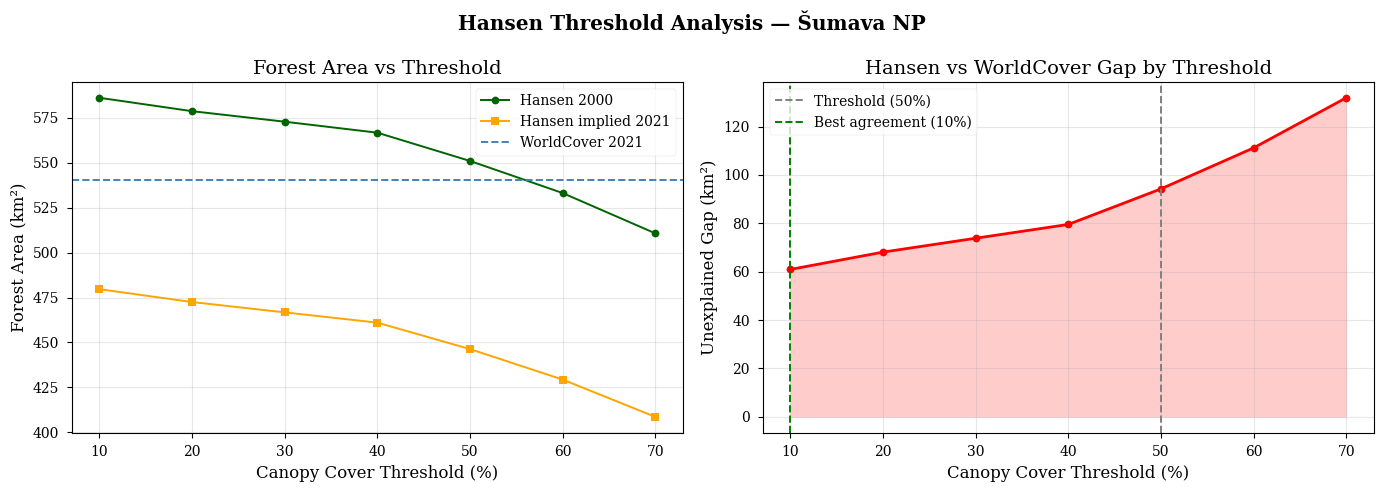

In [19]:
def plot_area_distribution_aggrement_hansen_wcover(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Hansen Threshold Analysis — Šumava NP', fontweight='bold')

    # Forest area vs threshold
    axes[0].plot(df['threshold'], df['forest_2000'], 'o-', 
                color='darkgreen', label='Hansen 2000')
    axes[0].plot(df['threshold'], df['implied_2021'], 's-', 
                color='orange', label='Hansen implied 2021')
    axes[0].axhline(y=tree_area_km2, color='steelblue', 
                    linestyle='--', label='WorldCover 2021')
    axes[0].set_xlabel('Canopy Cover Threshold (%)')
    axes[0].set_ylabel('Forest Area (km²)')
    axes[0].set_title('Forest Area vs Threshold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Gap vs threshold
    axes[1].plot(df['threshold'], df['gap_km2'], 'o-', color='red', linewidth=2)
    axes[1].fill_between(df['threshold'], df['gap_km2'], alpha=0.2, color='red')
    axes[1].axvline(x=50, color='grey', linestyle='--', 
                    label='Threshold (50%)')
    axes[1].axvline(x=10, color='green', linestyle='--', 
                    label='Best agreement (10%)')
    axes[1].set_xlabel('Canopy Cover Threshold (%)')
    axes[1].set_ylabel('Unexplained Gap (km²)')
    axes[1].set_title('Hansen vs WorldCover Gap by Threshold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURE_PATH / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
plot_area_distribution_aggrement_hansen_wcover(areas_thresholds_df.copy())

The problem with using Hansen directly for deforestation

Hansen flags all forest loss — it cannot distinguish:

Hansen lossyear = 22:

Could be → illegal logging      ← deforestation ✓

Could be → bark beetle die-off  ← NOT deforestation ✗

Could be → storm damage         ← NOT deforestation ✗

Could be → legal timber harvest ← debatable

If you train on all Hansen loss pixels as label=1, your classifier learns bark beetle signatures as deforestation — which is scientifically wrong for Šumava where bark beetle is the dominant disturbance.

In [20]:
worldcover_projection = worldcover.projection().nominalScale().getInfo()
treecover_projection = treecover.projection().nominalScale().getInfo()
lossYear_projection = lossYear.projection().nominalScale().getInfo()
print('WorldCover projection:', worldcover_projection)
print('Hansen treecover projection:', treecover_projection)
print('Hansen loss year projection:', lossYear_projection)

WorldCover projection: 9.276624232772797
Hansen treecover projection: 27.829872698318393
Hansen loss year projection: 27.829872698318393


In [21]:
lossYear_20m = (lossYear
    .unmask(0)
    .reproject(crs='EPSG:4326', scale=20))

In [25]:
# Combine Hansen 2000 forest mask and WorldCover 2021 core forest mask to get "confirmed" 
# forest pixels that were dense in 2000 and still core forest in 2021
was_forest_confirmed, was_forest_20m, wc_forest_core_20m = \
get_confirmed_forest_mask(
    hansen_treecover=treecover,
    worldcover_map=worldcover,
    scale=TARGET_SCALE_M,
    tree_class=WORLDCOVER_CLASS_TREES,
    hansen_tree_cover_threshold=HANSEN_CANOPY_COVER_THRESHOLD
)

In [26]:
was_forest_confirmed.projection().getInfo(), was_forest_confirmed.projection().nominalScale().getInfo()

({'type': 'Projection',
  'crs': 'EPSG:4326',
  'transform': [0.0001796630568239043, 0, 0, 0, -0.0001796630568239043, 0]},
 20)

In [27]:
print(f"Band names: {was_forest_confirmed.bandNames().getInfo()}")

Band names: ['confirmed_forest_mask']


In [28]:
confirmed_km2 = (was_forest_confirmed
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=20,
        maxPixels=1e10
    ).getInfo()).get('confirmed_forest_mask') / 1e6

forest2000_km2 = (was_forest_20m
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=20,
        maxPixels=1e10
    ).getInfo()).get('hansen_forest2000_mask', 0) / 1e6

wc_tree_area_km2 = (wc_forest_core_20m
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=20,
        maxPixels=1e10
    ).getInfo()).get('worldcover_core_forest_mask', 0) / 1e6

print(f'Hansen 2000 forest (>70%):       {forest2000_km2:.2f} km²')
print(f'Core WorldCover 2021 Trees(Edges removed):           {wc_tree_area_km2:.2f} km²')
print(f'Confirmed forest (both agree):   {confirmed_km2:.2f} km²')

Hansen 2000 forest (>70%):       510.69 km²
Core WorldCover 2021 Trees(Edges removed):           515.64 km²
Confirmed forest (both agree):   443.06 km²


Loss area by year (calculated): {'groups': [{'area_loss_year': 0, 'sum': 357475772.18337166}, {'area_loss_year': 1, 'sum': 13536.766481287339}, {'area_loss_year': 2, 'sum': 496542.9123474121}, {'area_loss_year': 3, 'sum': 279916.6453221938}, {'area_loss_year': 4, 'sum': 6497339.527909343}, {'area_loss_year': 5, 'sum': 1361918.3648769006}, {'area_loss_year': 6, 'sum': 125595.28770823759}, {'area_loss_year': 7, 'sum': 9846139.018420171}, {'area_loss_year': 8, 'sum': 2090633.0653195847}, {'area_loss_year': 9, 'sum': 4330655.8748791255}, {'area_loss_year': 10, 'sum': 4470268.399967449}, {'area_loss_year': 11, 'sum': 5600687.421118404}, {'area_loss_year': 12, 'sum': 1810330.945531868}, {'area_loss_year': 13, 'sum': 102557.60771448472}, {'area_loss_year': 14, 'sum': 642109.862694355}, {'area_loss_year': 15, 'sum': 52341.522662712545}, {'area_loss_year': 16, 'sum': 837038.5982421875}, {'area_loss_year': 17, 'sum': 402974.6502589806}, {'area_loss_year': 18, 'sum': 1702080.821740244}, {'area_lo

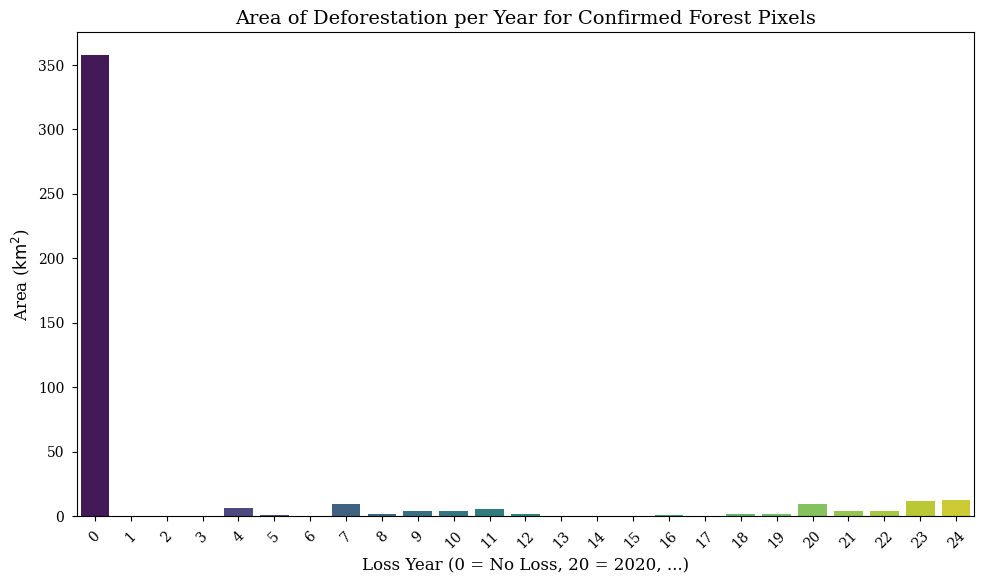

In [29]:
# Calculate area (in m2) for each loss year category
loss_area_by_year = calculate_loss_area_by_year(
    loss_year_img=lossYear_20m,
    mask=was_forest_confirmed,
    aoi=aoi,
    scale=TARGET_SCALE_M
)
print('Loss area by year (calculated):', loss_area_by_year)

# Convert to a dictionary mapping year -> area in km2
loss_area_km2 = {int(item['area_loss_year']): item['sum'] / 1e6 for item in loss_area_by_year.get('groups', [])}
loss_years = sorted(loss_area_km2.keys())
areas = [loss_area_km2[year] for year in loss_years]

plt.figure(figsize=(10, 6))
sns.barplot(x=loss_years, y=areas, palette='viridis')
plt.xlabel('Loss Year (0 = No Loss, 20 = 2020, ...)')
plt.ylabel(r'Area ($\mathrm{km}^2$)')
plt.title(r'Area of Deforestation per Year for Confirmed Forest Pixels')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(FIGURE_PATH / 'loss_year_area_histogram.png', dpi=150)
plt.show()

The 0 category strictly contains pixels that meet all three of these conditions simultaneously:

- They were dense forest in 2000 (Hansen).
- They were still forest in 2021 (WorldCover).
- Hansen's algorithms NEVER detected a loss event at any point between 2001 and 2024.

In [30]:
def create_deforested_label_mask(was_forest_confirmed, lossYear_20m,
                  band_name='label', year_start=20,year_end=24
                  ):

    if year_start == year_end:
        deforested_label_mask = (was_forest_confirmed
                .And(lossYear_20m.eq(year_start))
                .rename(band_name))
    else:
        deforested_label_mask = (was_forest_confirmed
                .And(lossYear_20m.gte(year_start))
                .And(lossYear_20m.lte(year_end))
                .rename(band_name))
    
    return deforested_label_mask

def create_stable_label_mask(was_forest_confirmed, lossYear_20m, band_name='stable_label'):
    stable_label_mask = (was_forest_confirmed
                .And(lossYear_20m.eq(0))
                .rename(band_name)) 
    return stable_label_mask

# Create deforested label masks for different time periods: 
# train: 2020-2021, val: 2022-2023, test: 2024 only (to avoid data leakage between train/val/test)
deforested_label_mask20_24 = create_deforested_label_mask(was_forest_confirmed, lossYear_20m, band_name='label', year_start=20, year_end=24)
deforested_label_train_mask = create_deforested_label_mask(was_forest_confirmed, lossYear_20m, band_name='label_train', year_start=20, year_end=21)
deforested_label_val_mask = create_deforested_label_mask(was_forest_confirmed, lossYear_20m, band_name='label_val', year_start=22, year_end=23)
deforested_label_test_mask = create_deforested_label_mask(was_forest_confirmed, lossYear_20m, band_name='label_test', year_start=24, year_end=24)

stable_label_mask = create_stable_label_mask(was_forest_confirmed, lossYear_20m, band_name='stable_label')


In [31]:
# calculate area of deforested and stable forest
def calculate_area(label_mask, aoi, scale=20, band_name='label'):
    area_km2 = (label_mask
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=scale,
            maxPixels=1e10
        ).getInfo()).get(band_name, 0) / 1e6
    return area_km2

total_deforested_area = calculate_area(deforested_label_mask20_24, aoi, scale=20, band_name='label')
deforested_area_train = calculate_area(deforested_label_train_mask, aoi, scale=20, band_name='label_train')
deforested_area_val = calculate_area(deforested_label_val_mask, aoi, scale=20, band_name='label_val')
deforested_label_test_area = calculate_area(deforested_label_test_mask, aoi, scale=20, band_name='label_test')
stable_area = calculate_area(stable_label_mask, aoi, scale=20, band_name='stable_label')

print(f'Total Deforested area (2020-2024): {total_deforested_area:.2f} km²')
print(f'Stable forest area (no loss): {stable_area:.2f} km²')
print(f'Deforested area for training (2020-2021): {deforested_area_train:.2f} km²')
print(f'Deforested area for validation (2022-2023): {deforested_area_val:.2f} km²')
print(f'Deforested area for testing (2024): {deforested_label_test_area:.2f} km²')

Total Deforested area (2020-2024): 43.01 km²
Stable forest area (no loss): 357.48 km²
Deforested area for training (2020-2021): 14.03 km²
Deforested area for validation (2022-2023): 16.32 km²
Deforested area for testing (2024): 12.67 km²


In [33]:
train_features, val_features, test_features_fair, test_features, s2_data_sets = \
get_all_features(
    aoi=aoi,
    bands=S2_BANDS,
    months=MONTHS,
)

Number of Sentinel-2 images for 2018 in AOI: 75
Number of Sentinel-2 images for 2019 in AOI: 61
Number of Sentinel-2 images for 2020 in AOI: 68
Number of Sentinel-2 images for 2021 in AOI: 45
Number of Sentinel-2 images for 2022 in AOI: 58
Number of Sentinel-2 images for 2023 in AOI: 66
Number of Sentinel-2 images for 2024 in AOI: 41
Number of Sentinel-2 images for 2025 in AOI: 84


In [37]:
# Check all bands present
print('Training bands:', train_features.bandNames().getInfo())
print('Validation bands:', val_features.bandNames().getInfo())
print('Test bands:', test_features.bandNames().getInfo())
print('Test fair bands:', test_features_fair.bandNames().getInfo())

Training bands: ['B4_y1', 'B8_y1', 'B11_y1', 'B12_y1', 'NDVI_y1', 'NBR_y1', 'B4_y2', 'B8_y2', 'B11_y2', 'B12_y2', 'NDVI_y2', 'NBR_y2', 'NDVI_slope', 'NBR_slope']
Validation bands: ['B4_y1', 'B8_y1', 'B11_y1', 'B12_y1', 'NDVI_y1', 'NBR_y1', 'B4_y2', 'B8_y2', 'B11_y2', 'B12_y2', 'NDVI_y2', 'NBR_y2', 'NDVI_slope', 'NBR_slope']
Test bands: ['B4_y1', 'B8_y1', 'B11_y1', 'B12_y1', 'NDVI_y1', 'NBR_y1', 'B4_y2', 'B8_y2', 'B11_y2', 'B12_y2', 'NDVI_y2', 'NBR_y2', 'NDVI_slope', 'NBR_slope']
Test fair bands: ['B4_y1', 'B8_y1', 'B11_y1', 'B12_y1', 'NDVI_y1', 'NBR_y1', 'B4_y2', 'B8_y2', 'B11_y2', 'B12_y2', 'NDVI_y2', 'NBR_y2', 'NDVI_slope', 'NBR_slope']


In [38]:
Map = geemap.Map()
Map.centerObject(aoi, 10)

vis_rgb = {'bands': ['B8','B4','B11'], 'min': 0, 'max': 3000}
vis_ndvi = {'min': 0, 'max': 1, 'palette': ['white','yellow','darkgreen']}

# Compare years side by side
Map.addLayer(s2_data_sets.get('s2_2020'), vis_rgb,  '2020 false colour', False)
Map.addLayer(s2_data_sets.get('s2_2022'), vis_rgb,  '2022 false colour', False)
Map.addLayer(s2_data_sets.get('s2_2024'), vis_rgb,  '2024 false colour', False)

Map.addLayer(s2_data_sets.get('s2_2020').select('NDVI'), vis_ndvi, '2020 NDVI', False)
Map.addLayer(s2_data_sets.get('s2_2024').select('NDVI'), vis_ndvi, '2024 NDVI', True)

# Add park boundary
Map.addLayer(
    ee.Image().paint(aoi, 0, 2),
    {'palette': 'red'}, 'Park boundary')

Map

Map(center=[48.985663647621195, 13.60326213433608], controls=(WidgetControl(options=['position', 'transparent_…

In [39]:
def sample_pixels(features, label_mask, aoi, scale=20, is_stable=False, num_points=500, seed=42, label_band_name='label'):
    """
    Sample pixels from features based on a label mask.
    Args:
        features: ee.Image with feature bands
        label_mask: ee.Image binary mask where pixels to sample are 1
        aoi: ee.Geometry defining the area of interest
        scale: sampling scale in meters
        is_stable: if True, label will be 1 for stable forest; if False, label will be 0 for deforested
        num_points: number of pixels to sample
        seed: random seed for reproducibility
        label_band_name: name of the band to add for labels
    """
    features_with_label = (features
        .updateMask(label_mask)
        .addBands(ee.Image.constant(1 if is_stable else 0).rename(label_band_name))) # stable=1, deforested=0

    samples = features_with_label.stratifiedSample(
        numPoints=num_points,
        classBand=label_band_name,
        region=aoi,
        scale=scale,
        seed=seed,
        geometries=False
    )
    return samples

In [40]:
stable_train_samples = sample_pixels(
    features=train_features,
    label_mask=stable_label_mask,
    aoi=aoi,
    scale=20,
    is_stable=True,
    num_points=500,
    seed=42,    label_band_name='label_train'
)

loss_train_samples = sample_pixels(
    features=train_features,
    label_mask=deforested_label_train_mask,
    aoi=aoi,
    scale=20,
    is_stable=False,
    num_points=500,
    seed=42,
    label_band_name='label_train'
)

# Combine stable and deforested samples into one training dataset
training = stable_train_samples.merge(loss_train_samples)
print('Stable samples:', stable_train_samples.size().getInfo())
print('Loss samples:',   loss_train_samples.size().getInfo())
print('Total:',          training.size().getInfo())

Stable samples: 500
Loss samples: 500
Total: 1000


In [41]:
# How many loss pixels exist in your AOI for 2020-2021?
loss_area_train = calculate_area(
    deforested_label_train_mask, aoi, scale=20, band_name='label_train')

print('Total Deforested area (2020-2021) train:', loss_area_train)

Total Deforested area (2020-2021) train: 14.025993642448874


In [42]:

def fit_random_forest_classifier(training, feature_band_names, label_band_name='label', num_trees=50, seed=42):
    """Train a Random Forest classifier on the provided training samples.
    
    Args:
        training: ee.FeatureCollection with feature bands and a label band
        feature_band_names: list of band names to use as features
        label_band_name: name of the band to use as the class label
        num_trees: number of trees in the random forest
        seed: random seed for reproducibility
    Returns:
        ee.Classifier: the trained random forest classifier
    """
    classifier = (ee.Classifier.smileRandomForest(
        numberOfTrees=num_trees,
        seed=seed
    ).train(
        features=training,
        classProperty=label_band_name,
        inputProperties=feature_band_names
    ))
    return classifier

feature_band_names = [band for band in train_features.bandNames().getInfo() if band != 'label_train']

# Train classifier
classifier = fit_random_forest_classifier(
    training=training,
    feature_band_names=feature_band_names,
    label_band_name='label_train',
    num_trees=50,
    seed=42
)
print('RF trained')

# Feature importances
importances = classifier.explain().getInfo()
# Correct
for band, importance in importances['importance'].items():
    print(f'  {band}: {importance:.4f}')

RF trained
  B11_y1: 39.3594
  B11_y2: 48.3405
  B12_y1: 44.2501
  B12_y2: 41.1275
  B4_y1: 48.9443
  B4_y2: 42.5948
  B8_y1: 43.3356
  B8_y2: 40.7395
  NBR_slope: 66.6751
  NBR_y1: 48.5139
  NBR_y2: 50.5260
  NDVI_slope: 43.7446
  NDVI_y1: 44.8211
  NDVI_y2: 47.8128


In [43]:
simplified_feature_bands = [
    'NDVI_y1', 'NBR_y1',
    'NDVI_y2', 'NBR_y2',
    'NDVI_slope', 'NBR_slope'
]

In [44]:
classifier_simple = fit_random_forest_classifier(
    training=training.select(simplified_feature_bands + ['label_train']),
    feature_band_names=simplified_feature_bands,
    label_band_name='label_train',
    num_trees=50,
    seed=42
)
print('RF with simplified features trained')
for band, imp in sorted(
    classifier_simple.explain().getInfo()['importance'].items(),
    key=lambda x: x[1], reverse=True):
    print(f'  {band:<15} {imp:.4f}')

RF with simplified features trained
  NBR_slope       129.0986
  NBR_y2          123.4260
  NBR_y1          120.0526
  NDVI_slope      115.9538
  NDVI_y2         108.0237
  NDVI_y1         95.9273


In [45]:
# Validation labels — only 2022-2023 to match val_features
stable_val_samples = sample_pixels(
    features=val_features,
    label_mask=stable_label_mask,
    aoi=aoi,
    scale=20,
    is_stable=True,
    num_points=400,
    seed=99,    label_band_name='label'
)

loss_val_samples = sample_pixels(
    features=val_features,
    label_mask=deforested_label_val_mask,
    aoi=aoi,
    scale=20,
    is_stable=False,
    num_points=400,
    seed=99,
    label_band_name='label'
)

validation = stable_val_samples.merge(loss_val_samples)
print('Validation samples:', validation.size().getInfo())

Validation samples: 800


In [46]:
validated = validation.classify(classifier_simple)

In [63]:
# Confusion matrix
error_matrix = validated.errorMatrix('label', 'classification')

print('Validation Results:')
print('Confusion matrix:')
print(error_matrix.getInfo())
print(f'Overall accuracy: {error_matrix.accuracy().getInfo():.4f}')
print(f'Kappa:            {error_matrix.kappa().getInfo():.4f}')

Validation Results:
Confusion matrix:
[[369, 31], [63, 337]]
Overall accuracy: 0.8825
Kappa:            0.7650


In [51]:
# Test labels — only 2024 to match test_features_fair and avoid data leakage from train/val
stable_test_samples = sample_pixels(
    features=test_features_fair,
    label_mask=stable_label_mask,
    aoi=aoi,
    scale=20,
    is_stable=True,
    num_points=400,
    seed=123,    label_band_name='label'
)

loss_test_samples = sample_pixels(
    features=test_features_fair,
    label_mask=deforested_label_test_mask,
    aoi=aoi,
    scale=20,
    is_stable=False,
    num_points=400,
    seed=123, label_band_name='label'
)

test = stable_test_samples.merge(loss_test_samples)
print('Test samples (2024):', test.size().getInfo())

Test samples (2024): 800


In [64]:
tested = test.classify(classifier_simple)
test_error_matrix = tested.errorMatrix('label', 'classification')
print('Test Results:')
print('Test Confusion matrix:')
print(test_error_matrix.getInfo())
print(f'Test Overall accuracy: {test_error_matrix.accuracy().getInfo():.4f}')
print(f'Test Kappa:            {test_error_matrix.kappa().getInfo():.4f}')

Test Results:
Test Confusion matrix:
[[353, 47], [81, 319]]
Test Overall accuracy: 0.8400
Test Kappa:            0.6800


In [53]:
# Predict on the entire AOI for 2024-2025 features
test_prediction = test_features.classify(classifier_simple)

# Mask predictions to only the "confirmed forest" pixels to focus on areas that were dense forest in 2000 and still core forest in 2021
prediction_masked_tested = test_prediction.updateMask(was_forest_confirmed)

In [ ]:
# How much of your predicted loss overlaps Hansen 2024?
is_predicted_deforested = prediction_masked_tested.eq(0)  # deforested=0, stable=1
hansen_loss_2024 = (lossYear_20m.eq(24)
    .And(was_forest_confirmed))

# Agreement pixels
agreement = (is_predicted_deforested
    .And(hansen_loss_2024))

# Prediction only — potential 2025 new loss
potential_new_loss = (is_predicted_deforested
    .And(hansen_loss_2024.Not())) # these are predicted deforested but not yet confirmed by Hansen 2024 — could be new loss in 2025 or false positives

# Hansen only — the model missed these
missed = (hansen_loss_2024
    .And(is_predicted_deforested.Not()))

def get_area(image):
    area = (image.selfMask()
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=20,
            maxPixels=1e10
        ).getInfo())
    return list(area.values())[0] / 1e6

print(f'Total Hansen confirmed Loss(2024): {get_area(hansen_loss_2024):.2f} km²')
print(f'Agrees with Hansen 2024:            {get_area(agreement):.2f} km²')
print(f'Hansen loss model missed(2024):           {get_area(missed):.2f} km²')
print(f'Potential new loss in 2025:         {get_area(potential_new_loss):.2f} km²')

Total Hansen confirmed Loss(2024): 12.67 km²
Agrees with Hansen 2024:            8.18 km²
Hansen loss model missed(2024):           4.48 km²
Potential new loss in 2025:         69.55 km²


In [ ]:
# Visualise new loss vs satellite basemap
Map = geemap.Map()
Map.centerObject(aoi, 12)
Map.add_basemap('SATELLITE')

# New loss — not in Hansen
Map.addLayer(
    potential_new_loss.selfMask(),
    {'min': 0, 'max': 1, 'palette': ['#ff0000']},
    'New loss not in Hansen'
)

# Hansen confirmed
Map.addLayer(
    agreement.selfMask(),
    {'min': 0, 'max': 1, 'palette': ['#ffa500']},
    'Agrees with Hansen'
)

# Hansen only — missed by model
Map.addLayer(
    missed.selfMask(),
    {'min': 0, 'max': 1, 'palette': ['#0000ff']},
    'Hansen loss missed by model'
)

Map.addLayer(
    ee.Image().paint(aoi, 0, 2),
    {'palette': '#ffffff'},
    'Šumava NP Boundary'
)

Map

Map(center=[48.985663647621195, 13.60326213433608], controls=(WidgetControl(options=['position', 'transparent_…

In [66]:
class_dist = (prediction_masked_tested
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=aoi,
        scale=20,
        maxPixels=1e10
    ).getInfo())

print('Predicted class distribution:', class_dist)

hist = class_dist.get('classification', {})
stable_px = hist.get('1', 0)
loss_px = hist.get('0', 0)
total_px = stable_px + loss_px

avg_pixel_area = (ee.Image(1)
    .reproject(crs='EPSG:4326', scale=20)
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=20,
        maxPixels=1e10
    ).getInfo().get('constant', 0))

stable_km2  = (stable_px * avg_pixel_area) / 1e6
loss_km2    = (loss_px * avg_pixel_area)  / 1e6
total_km2   = (total_px * avg_pixel_area) / 1e6

print(f"Out of 2024 and 2025 all pixels(Confirmed)\n")
print(f'Confirmed forest:      {confirmed_km2:.2f} km²')
print(f'Total predicted:       {total_km2:.2f} km²')
print(f'Predicted stable area: {stable_km2:.2f} km²')
print(f'Predicted loss area:   {loss_km2:.2f} km²')
print(f'Difference:            {abs(total_km2 - confirmed_km2):.2f} km²')

Predicted class distribution: {'classification': {'0': 295927.45490196074, '1': 1390581.0274509804}}
Out of 2024 and 2025 all pixels(Confirmed)

Confirmed forest:      443.06 km²
Total predicted:       443.11 km²
Predicted stable area: 365.36 km²
Predicted loss area:   77.75 km²
Difference:            0.05 km²


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SUMAVA NP FOREST DISTURBANCE DETECTION

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Study area:     682.34 $km^2$ (Sumava NP)

Forest mask:    443.06 $km^2$ (confirmed forest)

Model:          Random Forest (50 trees, 6 features)

Features:

  - NDVI_y1, NBR_y1   => baseline state
  - NDVI_y2, NBR_y2   => current state
  - NDVI_slope        => vegetation trend
  - NBR_slope         => disturbance trend <= strongest feature

Performance:

  - Validation 2022-2023  acc=0.88  kappa=0.765
  - Test       2023-2024  acc=0.84  kappa=0.68

Prediction 2024-2025(Confirmed):

  - Stable forest:          365.36 $km^2$  (82.5%)
  - Disturbed(loss):        77.75 $km^2$  (17.5%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━